# **실습03 : 다중분류 - Fashion MNIST**

* 패션 아이템 이미지 10가지 분류하기
    * 데이터 : 이미지(1, 32, 32) 6만장
    * 10가지 클래스로 분류하기 위한 모델 생성

![](https://www.researchgate.net/publication/346405197/figure/fig3/AS:962581560848384@1606508736352/Examples-of-Fashion-MNIST-dataset.ppm)


## **1.환경준비**

### (1) 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor

### (2) 필요 함수 생성

* 딥러닝을 위한 데이터로더 만들기

In [3]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
    """    pandas/numpy 데이터를 PyTorch 학습용 DataLoader와 검증 텐서로 변환합니다."""

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, x_val_tensor, y_val_tensor

* 학습을 위한 함수

In [4]:
def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""

    model.train()                               # 훈련 모드로 설정
    total_loss = 0

    for x, y in dataloader:                # (X, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)  # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 연결

        # Feed Forward
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지. 한 배치를 시작할 때 이전 배치의 gradient를 먼저 지우고, 현재 배치의 gradient만 계산
        pred = model(x)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()         # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()        # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트

        total_loss += loss.item() * x.size(0)       # 배치 평균 loss에 배치 크기를 곱해 배치 전체 loss로 누적


    return total_loss / len(dataloader.dataset)     # 전체 데이터 개수로 나누어 epoch 평균 loss 반환

* 검증을 위한 함수

In [5]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    """검증 데이터 전체에 대한 loss와 예측값을 반환합니다."""

    model.eval()         # 모델을 평가 모드로 설정

    with torch.no_grad():       # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [6]:
def dl_learning_curve(tr_loss_list, val_loss_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [7]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### (4) 데이터 셋

#### 1) 다운로드

In [8]:
train_dataset = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)

test_dataset = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.55MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.30MB/s]


#### 2) 데이터셋 정보

* 데이터셋 일반 정보

In [9]:
train_dataset, test_dataset

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

* 데이터셋의 x와 y

In [10]:
train_dataset.data.shape, train_dataset.targets.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

* y(target)의 클래스

In [11]:
classes = train_dataset.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

* 데이터 1건

In [12]:
train_dataset[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

* 데이터 이미지 확인

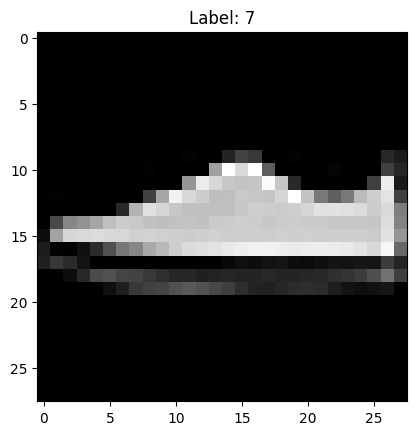

In [34]:
# n 바꿔가며 확인해보기
n = 20000
image, label = train_dataset.data[n], train_dataset.targets[n]

# 이미지 시각화
plt.imshow(image, cmap="gray")
plt.title(f"Label: {label}")
plt.show()

## **2.데이터 준비**

* 다운 받은 데이터셋은 다음의 전처리가 완료됨
    * x, y가 분리
    * train, test 분리
    * 스케일링

### (1) train은 데이터로더로 생성

In [23]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)

In [24]:
# 첫번째 배치만 로딩해서 살펴보기
for X, y in train_dataloader:
    print(f"Shape of X [batch, channels, height, width]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [batch, channels, height, width]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


### (2) validation, test 준비
* 데이터셋 분할
    * validation : 학습시, 에포크마다 성능 검증용
    * test : 모델 생성 후 최종 검증용
* dataset의 data 속성으로 데이터를 뽑으면 원본데이터가 나온다.
    * 스케일링 안된 데이터
    * 5000, 28, 28 : 3차원 데이터셋
* 그래서 모델링에 사용하려면 두가지 전처리를 다시 해줘야 함
    * 스케일링 : 원본데이터가 0~255 까지 숫자이므로, 255로 나눠주면 됨
    * 4차원 변환 : 5000, 1, 28, 28

#### 1) 데이터 분할 : test --> val, test

In [25]:
X_val, X_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]

In [26]:
X_val.shape, y_val.shape

(torch.Size([5000, 28, 28]), torch.Size([5000]))

#### 2) 스케일링

In [27]:
X_val = X_val / 255
X_test = X_test/ 255

#### 3) 3차원 데이터셋 --> 4차원 데이터셋
* 여기서 꼭 필요한 작업은 아니다.
* 하지만, 잠시 후에 배울 CNN 모델링에서 필요하다.
    * 이미지 한장의 구조는, [채널, 세로픽셀 수, 가로픽셀 수] 이다.
        * 채널 : 흑백 = 1, 컬러 = 3
* 그러므로 여기서도 동일한 전처리를 수행한다.

In [28]:
X_val = X_val.view(5000, 1, 28, 28)  # [1 * 28 * 28 이미지 5000장] 구조로 변환.
X_test = X_test.view(5000, 1, 28, 28)

print(X_val.shape, X_test.shape)

torch.Size([5000, 1, 28, 28]) torch.Size([5000, 1, 28, 28])


## **3.모델링**
* 다양한 구조로 모델을 2개 이상 생성하고 성능을 평가해 봅시다.


### (1) 모델1

* 모델 선언

In [31]:
n_feature = 28 * 28
n_class = 10

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Flatten(),                       # 이미지를 한 줄로 펼치기
    nn.Linear(n_feature, 200),          # 클래스 수만큼 출력
    nn.ReLU(),                          # 이미지를 한 줄로 펼치기
    nn.Linear(200, 150),                # 클래스 수만큼 출력
    nn.ReLU(),                          # 이미지를 한 줄로 펼치기
    nn.Linear(150, 100),                # 클래스 수만큼 출력
    nn.ReLU(),                          # 이미지를 한 줄로 펼치기
    nn.Linear(100, 50),                 # 클래스 수만큼 출력
    nn.ReLU(),                          # 이미지를 한 줄로 펼치기
    nn.Linear(50, 10)                   # 클래스 수만큼 출력
).to(device)

print(model1)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=200, bias=True)
  (2): ReLU()
  (3): Linear(in_features=200, out_features=150, bias=True)
  (4): ReLU()
  (5): Linear(in_features=150, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=50, bias=True)
  (8): ReLU()
  (9): Linear(in_features=50, out_features=10, bias=True)
)


* Loss function과 Optimizer

In [32]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.01)

* 학습

In [36]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val, y_val, model1, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.390399, val loss : 0.431680
Epoch 2, train loss : 0.379376, val loss : 0.455891
Epoch 3, train loss : 0.371052, val loss : 0.470121
Epoch 4, train loss : 0.370256, val loss : 0.482030
Epoch 5, train loss : 0.356577, val loss : 0.458970
Epoch 6, train loss : 0.362972, val loss : 0.444284
Epoch 7, train loss : 0.355625, val loss : 0.446152
Epoch 8, train loss : 0.355318, val loss : 0.450468
Epoch 9, train loss : 0.351266, val loss : 0.468264
Epoch 10, train loss : 0.354016, val loss : 0.542087
Epoch 11, train loss : 0.357085, val loss : 0.444346
Epoch 12, train loss : 0.341871, val loss : 0.441620
Epoch 13, train loss : 0.340908, val loss : 0.486527
Epoch 14, train loss : 0.339986, val loss : 0.448362
Epoch 15, train loss : 0.347427, val loss : 0.464731
Epoch 16, train loss : 0.340482, val loss : 0.471375
Epoch 17, train loss : 0.343592, val loss : 0.432811
Epoch 18, train loss : 0.335933, val loss : 0.498015
Epoch 19, train loss : 0.344646, val loss : 0.455836
Ep

* 학습 곡선

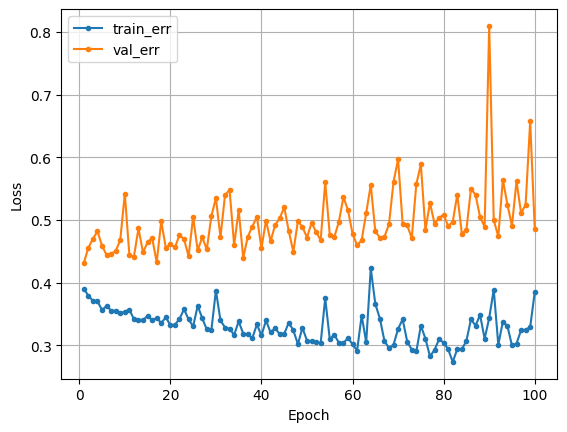

In [37]:
dl_learning_curve(tr_loss_list, val_loss_list)

* 모델 평가

In [38]:
_, pred = evaluate(X_test, y_test, model1, loss_fn, device)
pred[:5]

tensor([[ -3.3948,  -9.6489,   2.4172,  -6.0482,   0.2510, -19.1463,  -0.3038,
         -22.3036,  -4.6084, -32.4369],
        [ -6.2556,   9.7931, -10.2071,  17.8329,  -1.5776, -38.3805, -13.7663,
         -47.9165,  -1.3989, -16.1008],
        [  5.5886,   2.8957,   5.5962,   2.3904,   2.0814,   4.1862,   6.3562,
           4.4632,   7.1673,   2.9153],
        [-16.4763, -12.2585,   2.3927,   3.3585,  11.4180, -18.7354,  -0.4066,
         -14.7517,  -2.1437, -27.7123],
        [ -4.4261, -15.9347,  -0.2507,  -0.6046,   2.2300, -10.8136,   1.7034,
         -12.7254,  -4.3148, -19.0499]])

* 예측결과를 각 클래스별 확률값으로 변환 : nn.functional.softmax()
* 가장 확률이 높은 클래스 찾기 : np.argmax()

In [39]:
pred_prob = nn.functional.softmax(pred, dim=1)      # 클래스별 확률값으로 변환
pred_class = np.argmax(pred_prob.cpu().numpy(), axis=1) # 가장 높은 확률의 클래스를 최종 예측값으로 선택
pred_class[:5]


array([2, 3, 8, 4, 4])

* confusion matrix

In [40]:
cm = confusion_matrix(y_test.numpy(), pred_class)
cm

array([[452,   1,   3,   8,   1,   0,  23,   0,   5,   0],
       [ 10, 491,   0,   8,   3,   0,   5,   0,   2,   0],
       [ 20,   0, 339,   3,  84,   0,  31,   0,   2,   0],
       [ 27,   3,   1, 430,  20,   0,  17,   0,   2,   0],
       [  0,   0,  29,  14, 407,   0,  28,   0,   1,   0],
       [  0,   0,   0,   0,   0, 473,   0,  25,   2,  15],
       [156,   0,  39,  12,  47,   0, 252,   0,  12,   0],
       [  1,   0,   0,   0,   0,  14,   0, 446,   1,  38],
       [  1,   0,   0,   3,   3,   1,  13,   1, 452,   0],
       [  0,   0,   0,   0,   0,   2,   0,   8,   1, 512]])

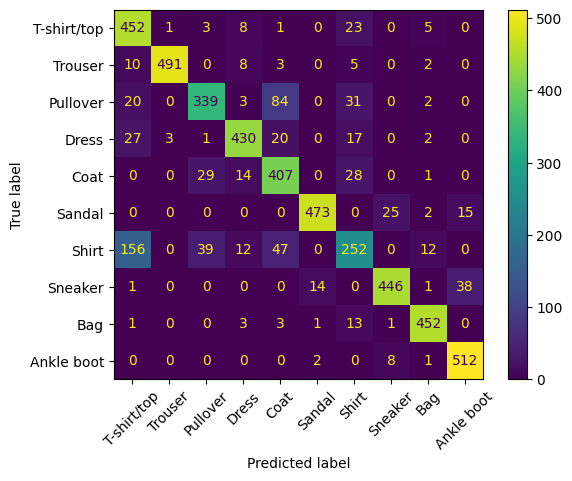

In [41]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
cm_display.plot()
plt.xticks(rotation=45)
plt.show()

* classification_report

In [42]:
print(classification_report(y_test.numpy(), pred_class))

              precision    recall  f1-score   support

           0       0.68      0.92      0.78       493
           1       0.99      0.95      0.97       519
           2       0.82      0.71      0.76       479
           3       0.90      0.86      0.88       500
           4       0.72      0.85      0.78       479
           5       0.97      0.92      0.94       515
           6       0.68      0.49      0.57       518
           7       0.93      0.89      0.91       500
           8       0.94      0.95      0.95       474
           9       0.91      0.98      0.94       523

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



### (2) 모델2

In [49]:
n_feature = 28 * 28
n_class = 10

# 모델 구조 설계
model2 = nn.Sequential(
    nn.Flatten(),                       # 이미지를 한 줄로 펼치기
    nn.Linear(n_feature, 300),          # 클래스 수만큼 출력
    nn.ReLU(),                          # 활성화 함수
    nn.Linear(300, 100),                # 클래스 수만큼 출력
    nn.ReLU(),                          # 활성화 함수
    nn.Linear(100, 50),                 # 클래스 수만큼 출력
    nn.ReLU(),                          # 활성화 함수
    nn.Linear(50, n_class)              # 클래스 수만큼 출력
    ).to(device)

print(model2)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=300, bias=True)
  (2): ReLU()
  (3): Linear(in_features=300, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=50, bias=True)
  (6): ReLU()
  (7): Linear(in_features=50, out_features=10, bias=True)
)


In [50]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.01)

In [51]:
epochs = 10
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model2, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val, y_val, model2, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.560118, val loss : 0.459872
Epoch 2, train loss : 0.429048, val loss : 0.437713
Epoch 3, train loss : 0.401711, val loss : 0.458214
Epoch 4, train loss : 0.378625, val loss : 0.439727
Epoch 5, train loss : 0.368620, val loss : 0.433356
Epoch 6, train loss : 0.359781, val loss : 0.403705
Epoch 7, train loss : 0.352114, val loss : 0.442899
Epoch 8, train loss : 0.350097, val loss : 0.436365
Epoch 9, train loss : 0.343374, val loss : 0.439223
Epoch 10, train loss : 0.338196, val loss : 0.445379


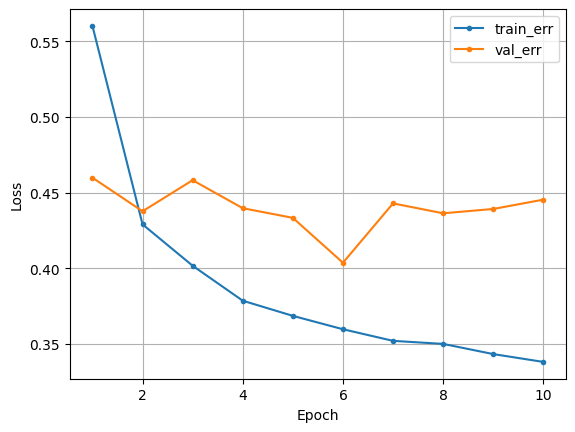

In [52]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [53]:
_, pred = evaluate(X_test, y_test, model2, loss_fn, device)
pred[:5]

tensor([[ -1.8190,  -3.1478,   1.9861,  -1.9343,   0.9015, -10.1254,   0.8005,
         -10.7944,  -1.8473,  -9.7456],
        [ -2.1097,   3.1087,  -6.5799,  13.7546,  -1.2836, -50.9825,  -3.6436,
         -82.5642, -16.6679, -44.3673],
        [  0.9033,  -2.3932,  -0.5083,  -0.8913,  -1.6922,  -5.4162,   1.0780,
         -10.0797,  -1.0529,  -7.1029],
        [ -5.6162,  -6.9618,   3.8616,   0.2104,  10.6852, -51.2470,   2.3185,
         -52.3821,  -2.8833, -40.1149],
        [ -3.4156,  -9.8914,   0.9485,  -3.1931,   3.9170, -14.3462,   4.3657,
         -20.3912,  -9.5194, -21.4997]])

In [54]:
pred_prob = nn.functional.softmax(pred, dim=1)           # 클래스별 확률값으로 변환
pred_class = np.argmax(pred_prob.cpu().numpy(), axis=1)  # 가장 높은 확률의 클래스를 최종 예측값으로 선택
pred_class[:5]


array([2, 3, 6, 4, 6])

### (3) 모델3

In [55]:
n_feature = 28 * 28
n_class = 10

# 모델 구조 설계
model3 = nn.Sequential(
    nn.Flatten(),                       # 이미지를 한 줄로 펼치기
    nn.Linear(n_feature, 300),          # 클래스 수만큼 출력
    nn.ReLU(),                          # 활성화 함수
    nn.Linear(300, n_class)            # 클래스 수만큼 출력
    ).to(device)

print(model3)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=300, bias=True)
  (2): ReLU()
  (3): Linear(in_features=300, out_features=10, bias=True)
)


In [56]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters(), lr=0.01)

In [57]:
epochs = 5
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model3, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val, y_val, model3, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.517406, val loss : 0.498713
Epoch 2, train loss : 0.407438, val loss : 0.450050
Epoch 3, train loss : 0.379948, val loss : 0.432658
Epoch 4, train loss : 0.361350, val loss : 0.428114
Epoch 5, train loss : 0.358131, val loss : 0.429638


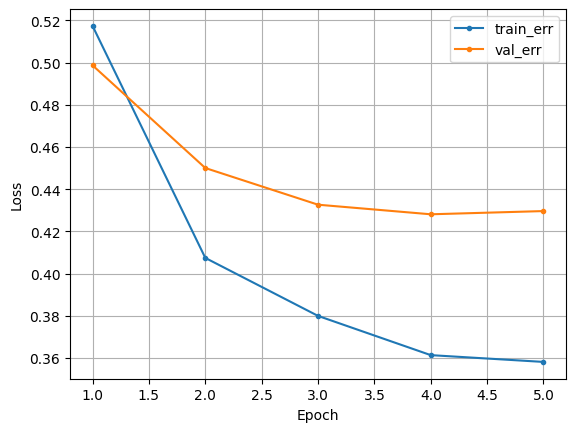

In [58]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [59]:
_, pred = evaluate(X_test, y_test, model2, loss_fn, device)
pred[:5]

tensor([[ -1.8190,  -3.1478,   1.9861,  -1.9343,   0.9015, -10.1254,   0.8005,
         -10.7944,  -1.8473,  -9.7456],
        [ -2.1097,   3.1087,  -6.5799,  13.7546,  -1.2836, -50.9825,  -3.6436,
         -82.5642, -16.6679, -44.3673],
        [  0.9033,  -2.3932,  -0.5083,  -0.8913,  -1.6922,  -5.4162,   1.0780,
         -10.0797,  -1.0529,  -7.1029],
        [ -5.6162,  -6.9618,   3.8616,   0.2104,  10.6852, -51.2470,   2.3185,
         -52.3821,  -2.8833, -40.1149],
        [ -3.4156,  -9.8914,   0.9485,  -3.1931,   3.9170, -14.3462,   4.3657,
         -20.3912,  -9.5194, -21.4997]])

In [60]:
pred_prob = nn.functional.softmax(pred, dim=1)           # 클래스별 확률값으로 변환
pred_class = np.argmax(pred_prob.cpu().numpy(), axis=1)  # 가장 높은 확률의 클래스를 최종 예측값으로 선택
pred_class[:5]


array([2, 3, 6, 4, 6])